# Behavioral Feature Engineering for FOMO Investor Detection

**Objective:**  
Engineer discriminative behavioral features for detecting FOMO (Fear Of Missing Out) investors in an **unsupervised setting**.

**Core Feature Engineering Philosophy:**  
*"Features should capture ANOMALIES and MOMENTUM rather than normal states."*  
Instead of measuring absolute values, we construct features that amplify behavioral extremes — deviations, velocity, behavioral instability, and loss of discipline.

**Scope:**  
This notebook covers pure Feature Engineering, Feature Diagnostics, and Feature Quality Analysis. It explicitly **does not** perform clustering, classification, or model training.

**Pipeline Overview:**
1. Data loading & join (`enriched_trades_train.csv` + `market_data.csv`)
2. Feature engineering across 4 behavioral groups
3. Distribution diagnostics
4. Outlier-robust transformation (Yeo-Johnson → RobustScaler)
5. Variance threshold filtering
6. Multicollinearity filtering (Spearman + VIF)
7. Unsupervised feature importance via PCA loadings
8. Export final feature dataset

## 1. Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Loading & Join

We load both source files:
- `enriched_trades_train.csv` — trade-level records per investor
- `market_data.csv` — daily market signals per asset

Since `enriched_trades_train.csv` already carries the key market columns (pre-joined upstream), we use it directly after renaming for consistency. The `market_data.csv` is loaded for reference and to backfill any nulls that may exist from the original join.

> **Note:** `totalValue` is renamed to `total_value` for PEP8-compliant naming throughout the pipeline.

In [30]:
# Load source files
trades = pd.read_csv('enriched_trades_train.csv')
market = pd.read_csv('market_data.csv')

# Standardize column naming
trades = trades.rename(columns={'totalValue': 'total_value'})

# Parse and sort timestamps
trades['timestamp'] = pd.to_datetime(trades['timestamp'])
market['timestamp'] = pd.to_datetime(market['timestamp'])
trades = trades.sort_values(['investor_id', 'timestamp']).reset_index(drop=True)

# Derive date column for daily aggregations
trades['date'] = trades['timestamp'].dt.date

print(f"Trades: {trades.shape[0]:,} rows × {trades.shape[1]} columns")
print(f"Market: {market.shape[0]:,} rows × {market.shape[1]} columns")
print(f"Unique investors: {trades['investor_id'].nunique():,}")
print(f"Unique assets:    {trades['asset_id'].nunique():,}")
trades.head()

Trades: 120,594 rows × 21 columns
Market: 193,040 rows × 11 columns
Unique investors: 10,534
Unique assets:    172


,investor_id,asset_id,timestamp,side,price,quantity,channel,total_value,risk_level,investment_capacity_ordinal,...,market_price,return_1d,return_5d,volatility_5d,volatility_10d,ma_5d,ma_20d,price_above_ma20,rsi_14,date
0,0004718496C71D464F57,GRS014003032,2021-03-19,BUY,8.5664,250.0,Phone Banking,2141.600,1.5,3.0,...,8.5664,-0.219534,-0.281342,0.193264,0.131922,12.147072,12.252608,0.699149,31.522188,2021-03-19
1,0004718496C71D464F57,GRS495003006,2021-04-19,BUY,5.1300,1500.0,Phone Banking,7695.000,1.5,3.0,...,5.1300,-0.050000,-0.046468,0.029544,0.022338,5.318000,5.297170,0.968442,44.424338,2021-04-19
2,0004718496C71D464F57,GRS014003032,2021-04-27,SELL,2.7000,727.0,Phone Banking,1962.900,1.5,3.0,...,2.7000,0.044084,0.150895,0.197133,0.215814,2.165200,4.483416,0.602219,31.033841,2021-04-27
3,0004718496C71D464F57,GRS434003000,2022-02-24,SELL,8.1550,1233.0,Phone Banking,10055.115,1.5,3.0,...,8.1550,-0.068000,-0.065330,0.032201,0.026408,8.590000,8.590000,0.949360,35.917800,2022-02-24
4,0004718496C71D464F57,GRS014003032,2022-02-24,SELL,1.4100,5000.0,Phone Banking,7050.000,1.5,3.0,...,1.4100,-0.105330,-0.089147,0.049501,0.035892,1.534200,1.547300,0.911265,38.827459,2022-02-24


In [31]:
# Null check — market columns in trades (from upstream join)
market_cols_in_trades = ['rsi_14', 'price_above_ma20', 'volatility_5d', 'return_1d', 'return_5d']
null_summary = trades[market_cols_in_trades].isna().sum()
print("Null counts in market columns:")
print(null_summary)

# Backfill nulls from market_data using asset_id + timestamp join
null_ratio = trades[market_cols_in_trades].isna().mean()
if null_ratio.max() > 0:
    print(f"\nBackfilling from market_data.csv (max null ratio: {null_ratio.max():.1%})")
    market_lookup = market.set_index(['asset_id', 'timestamp'])
    for col in market_cols_in_trades:
        if col in market_lookup.columns:
            mask = trades[col].isna()
            if mask.sum() > 0:
                idx = trades.loc[mask, ['asset_id', 'timestamp']]
                filled = idx.apply(
                    lambda r: market_lookup.loc[(r['asset_id'], r['timestamp']), col]
                    if (r['asset_id'], r['timestamp']) in market_lookup.index else np.nan, axis=1
                )
                trades.loc[mask, col] = filled.values
    print("Backfill complete.")

Null counts in market columns:
rsi_14              1392
price_above_ma20     278
volatility_5d       1113
return_1d           1040
return_5d           1113
dtype: int64

Backfilling from market_data.csv (max null ratio: 1.2%)
Backfill complete.


## 3. Feature Group A — Raw Investor-Level Aggregations

Các đặc trưng trong nhóm này được tổng hợp **trực tiếp từ các cột có sẵn trong dataset** — không tạo ra khái niệm mới. Đây là baseline profile của nhà đầu tư dựa trên dữ liệu giao dịch thô.

| Feature | Cột nguồn | Logic |
|---|---|---|
| `risk_level` | risk_level | Hồ sơ rủi ro — static per investor (lấy first value) |
| `investment_capacity_ordinal` | investment_capacity_ordinal | Năng lực đầu tư — static per investor |
| `trade_count` | timestamp | Tổng số lệnh giao dịch |
| `sell_buy_ratio` | side | Σ lệnh bán / Σ lệnh mua |
| `mean_rsi_at_trade` | rsi_14 | RSI trung bình tại thời điểm giao dịch |
| `std_rsi_at_trade` | rsi_14 | Độ phân tán RSI — cao = giao dịch ở nhiều môi trường thị trường |
| `mean_volatility_5d` | volatility_5d | Volatility 5 ngày trung bình tại thời điểm giao dịch |
| `mean_volatility_10d` | volatility_10d | Volatility 10 ngày trung bình |
| `mean_return_1d` | return_1d | Lợi suất 1 ngày trung bình tại thời điểm giao dịch |
| `mean_return_5d_all` | return_5d | Lợi suất 5 ngày trung bình (tất cả lệnh kể cả bán) |
| `mean_price_above_ma20` | price_above_ma20 | Giá trung bình so với MA20 khi giao dịch |
| `avg_trade_value` | total_value | Giá trị trung bình mỗi lệnh |

> **Lưu ý:** `risk_level` và `investment_capacity_ordinal` hầu như không đổi trong lịch sử giao dịch của mỗi investor (> 99% investor chỉ có 1 giá trị duy nhất), nên lấy `first()` là đại diện chính xác.

In [32]:
def build_raw_features(df):
    """Aggregate raw dataset columns to investor level.

    Không tạo ra khái niệm mới — chỉ tổng hợp (aggregate) các cột đã tồn tại
    trong dataset về investor level để tạo baseline profile.
    risk_level và investment_capacity_ordinal là static per investor (lấy first).
    """
    buy_df  = df[df['side'] == 'BUY']
    sell_df = df[df['side'] == 'SELL']

    buy_count  = buy_df.groupby('investor_id').size()
    sell_count = sell_df.groupby('investor_id').size()

    # sell_buy_ratio: dùng sentinel -1 để phân biệt "không có BUY" (never bought)
    # với "có BUY nhưng không có SELL" (ratio = 0.0).
    # fillna(0) sẽ gộp 2 behavioral states khác nhau vào cùng giá trị — sai về ngữ nghĩa.
    # Sentinel -1 giúp downstream models/clustering nhận ra "never bought" là state riêng.
    all_investors = df['investor_id'].unique()
    sell_buy_ratio = (
        sell_count.reindex(all_investors) / buy_count.reindex(all_investors)
    ).fillna(-1)  # -1 = investor chưa từng có BUY trade

    features = pd.DataFrame({
        # ── Investor profile (static fields) ──────────────────────────────
        'risk_level':                  df.groupby('investor_id')['risk_level'].first(),
        'investment_capacity_ordinal': df.groupby('investor_id')['investment_capacity_ordinal'].first(),

        # ── Activity & direction ──────────────────────────────────────────
        'trade_count':                 df.groupby('investor_id').size(),
        'sell_buy_ratio':              sell_buy_ratio,

        # ── Market context at time of trading ─────────────────────────────
        'mean_rsi_at_trade':           df.groupby('investor_id')['rsi_14'].mean(),
        'std_rsi_at_trade':            df.groupby('investor_id')['rsi_14'].std(),
        'mean_volatility_5d':          df.groupby('investor_id')['volatility_5d'].mean(),
        'mean_volatility_10d':         df.groupby('investor_id')['volatility_10d'].mean(),
        'mean_return_1d':              df.groupby('investor_id')['return_1d'].mean(),
        'mean_return_5d_all':          df.groupby('investor_id')['return_5d'].mean(),
        'mean_price_above_ma20':       df.groupby('investor_id')['price_above_ma20'].mean(),

        # ── Trade size ────────────────────────────────────────────────────
        'avg_trade_value':             df.groupby('investor_id')['total_value'].mean(),
    }).fillna(0)

    return features


raw_features = build_raw_features(trades)
print(f'Group A (raw) — {raw_features.shape[1]} features × {raw_features.shape[0]:,} investors')
print(f'  sell_buy_ratio = -1 (never bought): {(raw_features["sell_buy_ratio"] == -1).sum():,} investors')
raw_features.describe()


Group A (raw) — 12 features × 10,534 investors
  sell_buy_ratio = -1 (never bought): 6,431 investors


,risk_level,investment_capacity_ordinal,trade_count,sell_buy_ratio,mean_rsi_at_trade,std_rsi_at_trade,mean_volatility_5d,mean_volatility_10d,mean_return_1d,mean_return_5d_all,mean_price_above_ma20,avg_trade_value
count,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,1.053400e+04
mean,2.469622,1.459275,11.448073,-0.132060,51.248449,7.015823,0.031790,0.031383,-0.002312,-0.005881,0.996347,4.083455e+03
std,0.856298,0.781687,42.406633,1.575053,11.288415,7.214967,0.025207,0.020805,0.032024,0.065639,0.084539,2.926685e+04
min,0.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,-0.509615,-0.632107,0.000000,1.705303e-14
25%,2.000000,1.000000,1.000000,-1.000000,44.817708,0.000000,0.017135,0.018708,-0.013175,-0.031206,0.968296,2.994474e+02
50%,2.500000,1.000000,2.000000,-1.000000,51.169105,5.743236,0.025414,0.026227,-0.000254,-0.001068,1.002755,1.238929e+03
75%,3.000000,2.000000,7.000000,0.666667,57.961599,13.007247,0.037279,0.037076,0.011121,0.024834,1.034648,3.345182e+03
max,4.500000,4.000000,1447.000000,51.000000,99.999965,47.600848,0.316516,0.221392,0.300000,1.119205,2.374368,1.433403e+06


## 4. Feature Group B — Engineered Behavioral Features

Các đặc trưng được **tạo mới từ behavioral logic** — không có sẵn trực tiếp trong dataset. Mỗi feature thiết kế để bắt một chiều tâm lý FOMO cụ thể mà các cột raw không thể hiện trực tiếp.

### Group B1: Trend-Chasing Intensity

FOMO investors characteristically buy assets that are already overheated. These features capture the aggressiveness of momentum-chasing behavior.

In [33]:
def engineer_trend_chasing(df):
    """Captures aggressive buying behavior in overheated market conditions."""
    # df.copy() để tránh side effect: tính _price_z không nên ghi vào DataFrame gốc
    df = df.copy()
    df_buy = df[df['side'] == 'BUY'].copy()
    features = pd.DataFrame(index=df['investor_id'].unique())

    # Feature 1: extreme_green_chasing_ratio
    # Share of BUY value executed when RSI > 75 (extreme overbought)
    # Denominator uses total_buy_value to normalize by trading activity
    overheated_buys = df_buy[df_buy['rsi_14'] > 75].groupby('investor_id')['total_value'].sum()
    total_buy_value = df_buy.groupby('investor_id')['total_value'].sum()
    features['extreme_green_chasing_ratio'] = (overheated_buys / total_buy_value).fillna(0)

    # Feature 2: price_premium_zscore
    # 90th percentile of per-asset z-scored price premium — BUY trades only.
    # Z-score normalizes across assets so cross-asset comparisons are fair.
    # Dùng BUY-only vì FOMO là hành vi mua vào lúc giá đã cao — SELL không liên quan.
    df_buy['_price_z'] = df_buy.groupby('asset_id')['price_above_ma20'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )
    features['price_premium_zscore'] = (
        df_buy.groupby('investor_id')['_price_z'].quantile(0.90).fillna(0)
    )

    # Feature 3: momentum_buy_intensity
    # Mean 5-day return of assets at time of BUY — higher means buying into green streaks
    features['momentum_buy_intensity'] = df_buy.groupby('investor_id')['return_5d'].mean().fillna(0)

    return features

f_trend = engineer_trend_chasing(trades)
print(f'Trend-chasing features: {f_trend.shape}')
f_trend.describe()


Trend-chasing features: (10534, 3)


,extreme_green_chasing_ratio,price_premium_zscore,momentum_buy_intensity
count,5360.000000,5360.000000,5360.000000
mean,0.033573,0.514015,-0.023513
std,0.124005,0.983509,0.084396
min,0.000000,-3.202477,-0.853571
25%,0.000000,-0.171298,-0.052657
50%,0.000000,0.486766,-0.015613
75%,0.000000,1.144825,0.016062
max,1.000000,4.327520,0.459574


### Group B2: Position Sizing Instability

Disciplined investors size positions relative to their risk capacity. FOMO investors break this rule — they bet larger precisely when the market is most volatile.

In [34]:
def engineer_position_sizing(df):
    """Captures breakdowns in position sizing discipline."""
    features = pd.DataFrame(index=df['investor_id'].unique())

    # Feature 4: position_size_volatility
    # Std dev of position_size_ratio — high volatility = erratic capital allocation
    features['position_size_volatility'] = df.groupby('investor_id')['position_size_ratio'].std().fillna(0)

    # Feature 5: risk_capacity_mismatch_score
    # Spearman correlation between position size and asset volatility
    # Positive value = investor takes bigger positions in more volatile assets (FOMO signal)
    # Requires min 5 trades to compute a stable correlation
    def calc_corr(group):
        if len(group) < 5:
            return np.nan
        c = group['position_size_ratio'].corr(group['volatility_5d'], method='spearman')
        return c if not pd.isna(c) else 0.0

    features['risk_capacity_mismatch_score'] = df.groupby('investor_id').apply(calc_corr)

    # Feature 6: trade_value_spike_ratio
    # Share of trades where total_value exceeds the investor's own 90th percentile
    # Per-investor threshold prevents wealthier investors from dominating the signal
    inv_90th = df.groupby('investor_id')['total_value'].quantile(0.9)

    def spike_ratio(group):
        th = inv_90th.loc[group.name]
        return (group['total_value'] > th).mean()

    features['trade_value_spike_ratio'] = df.groupby('investor_id').apply(spike_ratio)

    return features.fillna(0)

f_position = engineer_position_sizing(trades)
print(f"Position sizing features: {f_position.shape}")
f_position.describe()

Position sizing features: (10534, 3)


,position_size_volatility,risk_capacity_mismatch_score,trade_value_spike_ratio
count,10534.000000,10534.000000,10534.000000
mean,0.064229,-0.040588,0.155060
std,0.200802,0.210511,0.173864
min,0.000000,-1.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.006209,0.000000,0.108696
75%,0.052004,0.000000,0.250000
max,6.670023,1.000000,0.500000


### Group B3: Behavioral Velocity

FOMO-driven trading is impulsive — investors act fast, cluster trades in short windows, and prefer low-friction digital channels.

In [35]:
def engineer_behavioral_velocity(df):
    """Captures impulsive, high-frequency trading execution patterns."""
    df = df.copy()
    features = pd.DataFrame(index=df['investor_id'].unique())

    # Time difference between consecutive trades per investor (in minutes)
    df['time_diff_min'] = (
        df.groupby('investor_id')['timestamp']
        .diff()
        .dt.total_seconds() / 60
    )

    # Feature 7: impulsive_trade_frequency
    # Count of trade intervals < 60 minutes — raw impulse episode count
    features['impulsive_trade_frequency'] = (
        df.groupby('investor_id')['time_diff_min']
        .apply(lambda x: (x < 60).sum())
    )

    # Feature 8: short_interval_trade_ratio
    # Proportion of trade intervals < 30 minutes — normalized for total activity
    features['short_interval_trade_ratio'] = (
        df.groupby('investor_id')['time_diff_min']
        .apply(lambda x: (x < 30).mean())
    )

    # Feature 9: digital_impulse_ratio
    # Share of trades via Internet Banking — lowest-friction, most impulsive channel
    df['is_digital'] = df['channel'].isin(['Internet Banking'])
    features['digital_impulse_ratio'] = df.groupby('investor_id')['is_digital'].mean()

    return features.fillna(0)

f_velocity = engineer_behavioral_velocity(trades)
print(f"Behavioral velocity features: {f_velocity.shape}")
f_velocity.describe()

Behavioral velocity features: (10534, 3)


,impulsive_trade_frequency,short_interval_trade_ratio,digital_impulse_ratio
count,10534.000000,10534.000000,10534.000000
mean,4.078413,0.151213,0.547509
std,27.212044,0.227745,0.492273
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,1.000000,0.285714,1.000000
max,1176.000000,0.952381,1.000000


### Group B4: Timing Bias & Recency

FOMO investors react to market noise at emotionally charged moments — the opening bell, the closing panic, or periods of recent market momentum.

In [36]:
def engineer_timing_bias(df):
    """Captures emotional trading patterns tied to market session timing."""
    df = df.copy()
    features = pd.DataFrame(index=df['investor_id'].unique())

    df['hour'] = df['timestamp'].dt.hour

    # Feature 10: market_open_trade_bias
    # Share of trades during the opening hour (9–10 AM)
    # FOMO investors rush to buy at the bell, fearing they'll miss the morning move
    features['market_open_trade_bias'] = (
        df.groupby('investor_id')['hour']
        .apply(lambda x: ((x >= 9) & (x <= 10)).mean())
    )

    # Feature 11: late_session_trade_bias
    # Share of trades in the closing hour (14–15 PM)
    # Late-session FOMO = panic buying before market closes
    features['late_session_trade_bias'] = (
        df.groupby('investor_id')['hour']
        .apply(lambda x: ((x >= 14) & (x <= 15)).mean())
    )

    # Feature 12: recency_trading_score
    # Days since last trade relative to the dataset's max date
    # Using dataset max (not today) ensures reproducibility
    reference_date = df['timestamp'].max()
    last_trade = df.groupby('investor_id')['timestamp'].max()
    features['recency_trading_score'] = (reference_date - last_trade).dt.days

    return features.fillna(0)

f_timing = engineer_timing_bias(trades)
print(f"Timing bias features: {f_timing.shape}")
f_timing.describe()

Timing bias features: (10534, 3)


,market_open_trade_bias,late_session_trade_bias,recency_trading_score
count,10534.0,10534.0,10534.000000
mean,0.0,0.0,331.701348
std,0.0,0.0,241.097773
min,0.0,0.0,0.000000
25%,0.0,0.0,106.000000
50%,0.0,0.0,289.000000
75%,0.0,0.0,533.000000
max,0.0,0.0,870.000000


## 4b. Feature Group C — Sell-Side Behavior & Asset Concentration

Hai chiều hành vi còn thiếu trong Group B — đây là tín hiệu FOMO đến từ *phía bán* và *mức độ tập trung tài sản*:

| Feature | Nguồn cột | Logic FOMO |
|---|---|---|
| `asset_concentration_ratio` | asset_id, investor_id | `n_unique_assets / trade_count` — thấp = dồn vào ít tài sản hot, không diversify |
| `win_loss_ratio` | return_1d, side=SELL | Tỷ lệ lệnh bán có `return_1d > 0` — thấp = hay bán lúc thị trường đang xuống (panic sell) |
| `avg_holding_period` | timestamp, BUY→SELL match | Số ngày trung bình giữ tài sản từ khi mua đến khi bán — thấp = trade nhanh (impatient FOMO) |

> **Lưu ý `avg_holding_period`:** Feature này chỉ tính được cho investors có cả BUY lẫn SELL trên cùng một asset (3,424 / 10,534 investors). Investors không có matched pair nhận giá trị 0. VIF filter có thể drop feature này nếu nó tương quan cao với `impulsive_trade_frequency`.

In [37]:
def engineer_sell_side(df):
    """Captures SELL-side behavioral patterns and portfolio concentration.

    Group B chỉ capture BUY-side behavior. Group C bổ sung:
    - asset_concentration_ratio: FOMO investors dồn vào 1-2 hot assets
    - win_loss_ratio: panic selling pattern (bán lúc thị trường đang xuống)
    - avg_holding_period: impatient trading — giữ ngắn vì sợ miss next move
    """
    all_investors = df['investor_id'].unique()
    sell_df = df[df['side'] == 'SELL'].copy()
    buy_df  = df[df['side'] == 'BUY'].copy()
    features = pd.DataFrame(index=all_investors)

    # Feature C1: asset_concentration_ratio
    # n_unique_assets / trade_count — thấp = highly concentrated
    # FOMO investors thường dồn vào 1-2 tài sản đang hot thay vì diversify
    n_unique = df.groupby('investor_id')['asset_id'].nunique()
    n_trades = df.groupby('investor_id').size()
    features['asset_concentration_ratio'] = (n_unique / n_trades)

    # Feature C2: win_loss_ratio
    # Tỷ lệ lệnh SELL có return_1d > 0 (bán lúc giá đang tăng)
    # Thấp = investor hay bán khi thị trường đang giảm → panic selling
    # Investors không có SELL nào → fillna(0)
    win_ratio = (
        sell_df.groupby('investor_id')['return_1d']
        .apply(lambda x: (x > 0).mean())
        .reindex(all_investors)
        .fillna(0)
    )
    features['win_loss_ratio'] = win_ratio

    # Feature C3: avg_holding_period
    # Số ngày trung bình từ BUY đến SELL kế tiếp của cùng asset
    # Methodology: với mỗi BUY, tìm SELL gần nhất về phía sau cùng investor + asset
    # Thấp = impatient — trade nhanh, không chờ long-term thesis
    # Investors không có matched pair → fillna(0)
    buy_sub  = buy_df[['investor_id','asset_id','timestamp']].rename(columns={'timestamp':'buy_ts'})
    sell_sub = sell_df[['investor_id','asset_id','timestamp']].rename(columns={'timestamp':'sell_ts'})
    merged   = buy_sub.merge(sell_sub, on=['investor_id','asset_id'], how='inner')
    merged   = merged[merged['sell_ts'] >= merged['buy_ts']]
    merged['holding_days'] = (merged['sell_ts'] - merged['buy_ts']).dt.days
    matched  = (
        merged.sort_values('holding_days')
              .groupby(['investor_id','buy_ts'])['holding_days']
              .first()
    )
    avg_hold = (
        matched.reset_index()
               .groupby('investor_id')['holding_days']
               .mean()
               .reindex(all_investors)
               .fillna(0)
    )
    features['avg_holding_period'] = avg_hold

    return features.fillna(0)


sell_features = engineer_sell_side(trades)
print(f'Group C (sell-side + concentration) — {sell_features.shape[1]} features × {sell_features.shape[0]:,} investors')
print(f'  asset_concentration_ratio  : [{sell_features["asset_concentration_ratio"].min():.3f}, {sell_features["asset_concentration_ratio"].max():.3f}]')
print(f'  win_loss_ratio             : [{sell_features["win_loss_ratio"].min():.3f}, {sell_features["win_loss_ratio"].max():.3f}]')
print(f'  avg_holding_period (days)  : [{sell_features["avg_holding_period"].min():.0f}, {sell_features["avg_holding_period"].max():.0f}]')
sell_features.describe()


Group C (sell-side + concentration) — 3 features × 10,534 investors
  asset_concentration_ratio  : [0.009, 1.000]
  win_loss_ratio             : [0.000, 1.000]
  avg_holding_period (days)  : [0, 786]


,asset_concentration_ratio,win_loss_ratio,avg_holding_period
count,10534.000000,10534.000000,10534.000000
mean,0.763811,0.464005,43.976225
std,0.305974,0.421037,98.454096
min,0.009009,0.000000,0.000000
25%,0.500000,0.000000,0.000000
50%,1.000000,0.500000,0.000000
75%,1.000000,1.000000,41.196524
max,1.000000,1.000000,786.000000


## 5. Combine Feature Pools — Group A ∪ Group B ∪ Group C

Ghép **Group A (raw)**, **Group B (engineered)**, và **Group C (sell-side + concentration)** vào một không gian feature duy nhất.

**Lý do gộp trước khi lọc:**  
Nếu lọc riêng từng nhóm, sẽ bỏ sót *cross-group redundancy* — ví dụ `mean_price_above_ma20` (RAW) và `price_premium_zscore` (ENG) đều đo mức độ đu đỉnh. Chỉ khi đưa vào Spearman và VIF cùng nhau mới phát hiện được sự chồng lấp này.  

Các bước lọc phía sau sẽ chọn lọc **không phân biệt nguồn gốc** — feature từ cả ba nhóm cạnh tranh ngang nhau.

Màu trực quan: **xanh dương** = Group A (RAW) · **cam** = Group B (ENG) · **xanh lá** = Group C (NEW)

In [38]:
# Ghép Group B engineered
engineered_features = pd.concat([f_trend, f_position, f_velocity, f_timing], axis=1)

# Pool toàn bộ: RAW → ENG → NEW (để dễ trace nguồn gốc)
all_features = pd.concat([raw_features, engineered_features, sell_features], axis=1).fillna(0)

# Dict theo dõi nguồn gốc từng feature — dùng xuyên suốt các bước lọc và visualization
FEATURE_SOURCE = (
    {col: 'RAW' for col in raw_features.columns}
    | {col: 'ENG' for col in engineered_features.columns}
    | {col: 'NEW' for col in sell_features.columns}
)
SOURCE_COLOR = {'RAW': 'steelblue', 'ENG': 'darkorange', 'NEW': 'mediumseagreen'}

print(f'Total feature pool : {all_features.shape[1]} features × {all_features.shape[0]:,} investors')
print(f'  Group A (raw)    : {raw_features.shape[1]} features')
print(f'  Group B (eng)    : {engineered_features.shape[1]} features')
print(f'  Group C (new)    : {sell_features.shape[1]} features')
print()
print('Full feature pool:')
for i, col in enumerate(all_features.columns, 1):
    print(f'  [{FEATURE_SOURCE[col]}] {i:2d}. {col}')

all_features.describe()


Total feature pool : 27 features × 10,534 investors
  Group A (raw)    : 12 features
  Group B (eng)    : 12 features
  Group C (new)    : 3 features

Full feature pool:
  [RAW]  1. risk_level
  [RAW]  2. investment_capacity_ordinal
  [RAW]  3. trade_count
  [RAW]  4. sell_buy_ratio
  [RAW]  5. mean_rsi_at_trade
  [RAW]  6. std_rsi_at_trade
  [RAW]  7. mean_volatility_5d
  [RAW]  8. mean_volatility_10d
  [RAW]  9. mean_return_1d
  [RAW] 10. mean_return_5d_all
  [RAW] 11. mean_price_above_ma20
  [RAW] 12. avg_trade_value
  [ENG] 13. extreme_green_chasing_ratio
  [ENG] 14. price_premium_zscore
  [ENG] 15. momentum_buy_intensity
  [ENG] 16. position_size_volatility
  [ENG] 17. risk_capacity_mismatch_score
  [ENG] 18. trade_value_spike_ratio
  [ENG] 19. impulsive_trade_frequency
  [ENG] 20. short_interval_trade_ratio
  [ENG] 21. digital_impulse_ratio
  [ENG] 22. market_open_trade_bias
  [ENG] 23. late_session_trade_bias
  [ENG] 24. recency_trading_score
  [NEW] 25. asset_concentration_rati

,risk_level,investment_capacity_ordinal,trade_count,sell_buy_ratio,mean_rsi_at_trade,std_rsi_at_trade,mean_volatility_5d,mean_volatility_10d,mean_return_1d,mean_return_5d_all,...,trade_value_spike_ratio,impulsive_trade_frequency,short_interval_trade_ratio,digital_impulse_ratio,market_open_trade_bias,late_session_trade_bias,recency_trading_score,asset_concentration_ratio,win_loss_ratio,avg_holding_period
count,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,10534.000000,...,10534.000000,10534.000000,10534.000000,10534.000000,10534.0,10534.0,10534.000000,10534.000000,10534.000000,10534.000000
mean,2.469622,1.459275,11.448073,-0.132060,51.248449,7.015823,0.031790,0.031383,-0.002312,-0.005881,...,0.155060,4.078413,0.151213,0.547509,0.0,0.0,331.701348,0.763811,0.464005,43.976225
std,0.856298,0.781687,42.406633,1.575053,11.288415,7.214967,0.025207,0.020805,0.032024,0.065639,...,0.173864,27.212044,0.227745,0.492273,0.0,0.0,241.097773,0.305974,0.421037,98.454096
min,0.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,-0.509615,-0.632107,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.009009,0.000000,0.000000
25%,2.000000,1.000000,1.000000,-1.000000,44.817708,0.000000,0.017135,0.018708,-0.013175,-0.031206,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,106.000000,0.500000,0.000000,0.000000
50%,2.500000,1.000000,2.000000,-1.000000,51.169105,5.743236,0.025414,0.026227,-0.000254,-0.001068,...,0.108696,0.000000,0.000000,1.000000,0.0,0.0,289.000000,1.000000,0.500000,0.000000
75%,3.000000,2.000000,7.000000,0.666667,57.961599,13.007247,0.037279,0.037076,0.011121,0.024834,...,0.250000,1.000000,0.285714,1.000000,0.0,0.0,533.000000,1.000000,1.000000,41.196524
max,4.500000,4.000000,1447.000000,51.000000,99.999965,47.600848,0.316516,0.221392,0.300000,1.119205,...,0.500000,1176.000000,0.952381,1.000000,0.0,0.0,870.000000,1.000000,1.000000,786.000000


## 6. Feature Quality Analysis Pipeline

Toàn bộ 27 features đi qua pipeline chất lượng **cùng nhau**. Không có bước nào xử lý các group riêng biệt.

### Step 1: Distribution Diagnostics

Trực quan hóa histogram + KDE của tất cả features ở trạng thái thô.  
Màu **xanh dương** = Group A (RAW) · **cam** = Group B (ENG) · **xanh lá** = Group C (NEW)

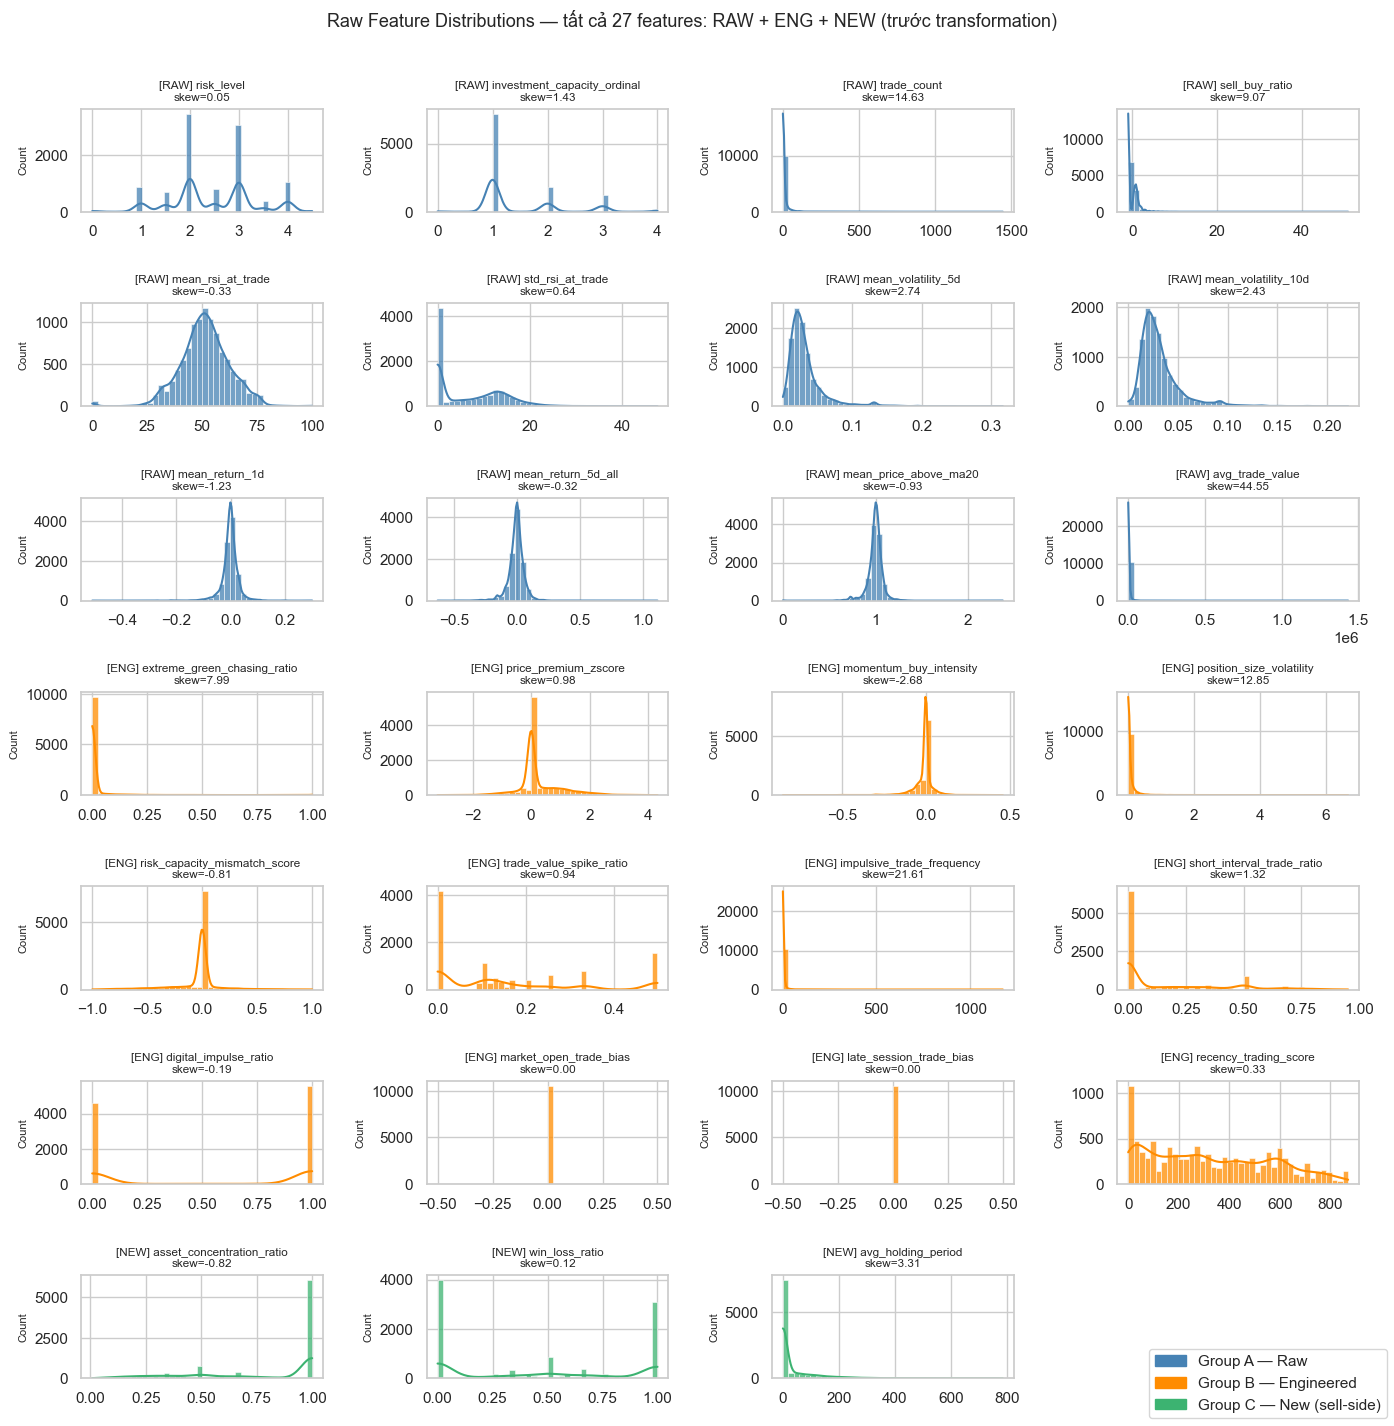

In [39]:
def plot_distributions(df_features, feature_source, source_color):
    cols = df_features.columns
    n_cols = 4
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = df_features[col].dropna()
        skew = data.skew()
        color = source_color[feature_source[col]]
        
        sns.histplot(data, kde=True, ax=ax, color=color, bins=40, alpha=0.75)
        
        src = feature_source[col]
        ax.set_title(f'[{src}] {col}\nskew={skew:.2f}', fontsize=8.5)
        ax.set_xlabel('')
        ax.set_ylabel('Count', fontsize=8)

    # Đã sửa logic chỗ này: dùng len(cols) thay vì (i + 1) để tránh lỗi UnboundLocalError nếu len(cols) == 0
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

    from matplotlib.patches import Patch
    fig.legend(
        handles=[
            Patch(color='steelblue', label='Group A — Raw'),
            Patch(color='darkorange', label='Group B — Engineered'),
            Patch(color='mediumseagreen', label='Group C — New (sell-side)')
        ],
        loc='lower right', fontsize=11
    )

    plt.suptitle(f'Raw Feature Distributions — tất cả {len(cols)} features: RAW + ENG + NEW (trước transformation)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_distributions(all_features, FEATURE_SOURCE, SOURCE_COLOR)

### Step 2: Outlier-Robust Transformation

Áp dụng cho toàn bộ 24 features. Thứ tự:
1. **Yeo-Johnson PowerTransformer** — normalize distribution shape (áp dụng trước)
2. **RobustScaler (IQR)** — center + scale dùng interquartile range, chống outlier (áp dụng sau)

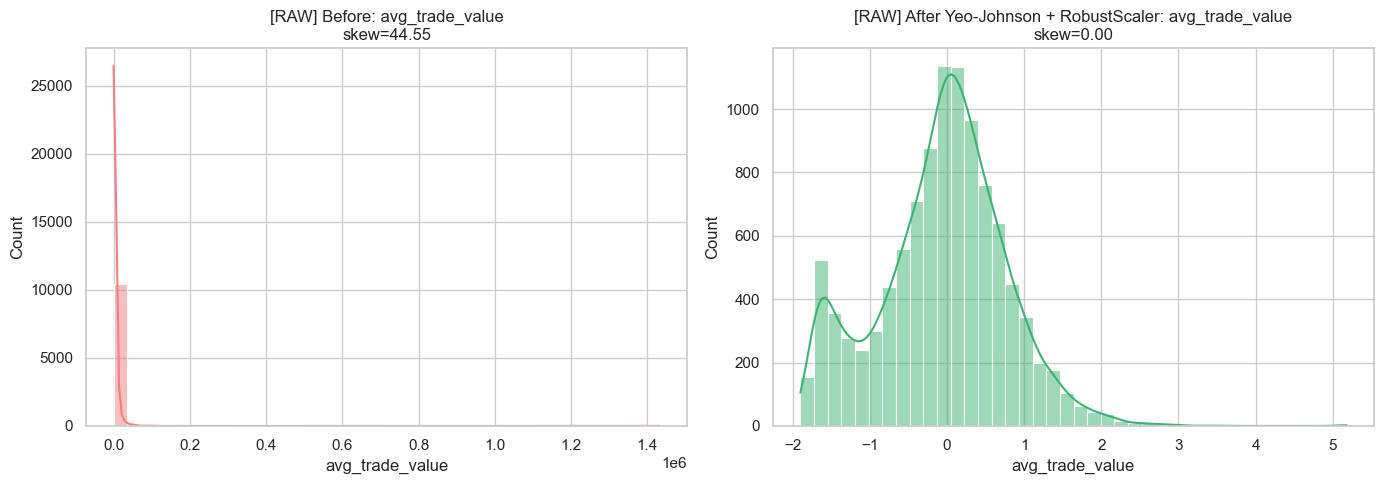

Most skewed: [RAW] avg_trade_value
Skew before : 44.547
Skew after  : 0.001


In [40]:
pt = PowerTransformer(method='yeo-johnson')
rs = RobustScaler()

all_features_scaled = pd.DataFrame(
    rs.fit_transform(pt.fit_transform(all_features)),
    columns=all_features.columns,
    index=all_features.index
)

# Trực quan hóa trước/sau cho feature có skew cao nhất
most_skewed = all_features.skew().abs().idxmax()
src_ms = FEATURE_SOURCE[most_skewed]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(all_features[most_skewed], kde=True, ax=ax1, color='lightcoral', bins=40)
ax1.set_title(f'[{src_ms}] Before: {most_skewed}\nskew={all_features[most_skewed].skew():.2f}')

sns.histplot(all_features_scaled[most_skewed], kde=True, ax=ax2, color='mediumseagreen', bins=40)
ax2.set_title(f'[{src_ms}] After Yeo-Johnson + RobustScaler: {most_skewed}\nskew={all_features_scaled[most_skewed].skew():.2f}')

plt.tight_layout()
plt.show()

print(f'Most skewed: [{src_ms}] {most_skewed}')
print(f'Skew before : {all_features[most_skewed].skew():.3f}')
print(f'Skew after  : {all_features_scaled[most_skewed].skew():.3f}')

### Step 3: Variance Threshold Filtering

Drop features có **variance < 0.01** sau transformation. Áp dụng trên toàn bộ 24 features.  
Features từ cả Group A lẫn Group B đều có thể bị drop nếu không có discriminative power.

*(Trên dataset hiện tại: `market_open_trade_bias` và `late_session_trade_bias` bị drop vì toàn bộ timestamp trong dataset chỉ lưu phần ngày — `hour = 0` với mọi bản ghi — nên variance = 0.)*

In [41]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(all_features_scaled)

kept_after_var   = all_features_scaled.columns[selector.get_support()].tolist()
dropped_by_var   = set(all_features_scaled.columns) - set(kept_after_var)

print(f'Threshold : variance < 0.01')
print(f'Dropped   : {len(dropped_by_var)}')
for col in dropped_by_var:
    print(f'  [{FEATURE_SOURCE[col]}] {col}  (var={all_features_scaled[col].var():.6f})')
print(f'Kept      : {len(kept_after_var)} / {len(all_features.columns)}')

X_filtered = all_features_scaled[kept_after_var]
X_filtered.shape

Threshold : variance < 0.01
Dropped   : 2
  [ENG] late_session_trade_bias  (var=0.000000)
  [ENG] market_open_trade_bias  (var=0.000000)
Kept      : 25 / 27


(10534, 25)

### Step 4: Multicollinearity Filtering — Spearman Rank Correlation

Loại các features trùng thông tin theo cặp. **Spearman** thay vì Pearson vì dữ liệu tài chính có quan hệ phi tuyến cao.

Ngưỡng: **|ρ| > 0.85**. Khi một cặp vượt ngưỡng, drop feature có *mean absolute correlation thấp hơn* (ít thông tin hơn về toàn bộ pool).

> **Cross-group detection:** Spearman có thể drop một RAW feature vì nó trùng thông tin với một ENG feature (và ngược lại). Đây là hành vi đúng — selection không phân biệt nguồn gốc.

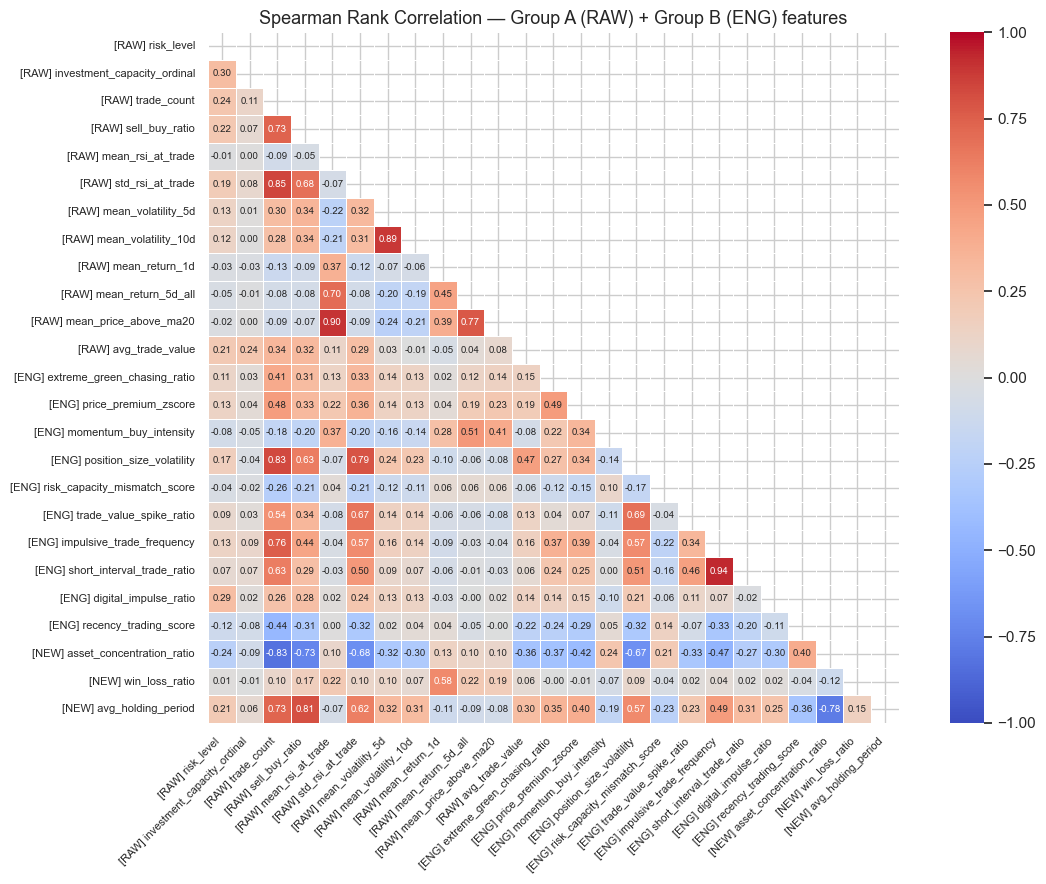

Threshold: |ρ| > 0.85
Pairs vượt ngưỡng:
  ρ=+0.89 | DROP [RAW] mean_volatility_10d | KEEP [RAW] mean_volatility_5d
  ρ=+0.90 | DROP [RAW] mean_rsi_at_trade | KEEP [RAW] mean_price_above_ma20
  ρ=+0.94 | DROP [ENG] short_interval_trade_ratio | KEEP [ENG] impulsive_trade_frequency

Total dropped: 3
Remaining    : 22 features


In [42]:
spearman_corr = X_filtered.corr(method='spearman')

# Heatmap với label nguồn gốc
labels = [f"[{FEATURE_SOURCE[c]}] {c}" for c in spearman_corr.columns]
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(
    spearman_corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.4,
    xticklabels=labels, yticklabels=labels, annot_kws={'size': 7}
)
plt.title('Spearman Rank Correlation — Group A (RAW) + Group B (ENG) features', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Drop highly correlated features — không phân biệt RAW hay ENG
high_corr_threshold = 0.85
to_drop_corr        = set()

print(f'Threshold: |ρ| > {high_corr_threshold}')
print('Pairs vượt ngưỡng:')
for i in range(len(spearman_corr.columns)):
    for j in range(i):
        if abs(spearman_corr.iloc[i, j]) > high_corr_threshold:
            col_i = spearman_corr.columns[i]
            col_j = spearman_corr.columns[j]
            mean_i = spearman_corr[col_i].abs().mean()
            mean_j = spearman_corr[col_j].abs().mean()
            drop = col_i if mean_i < mean_j else col_j
            keep = col_j if drop == col_i else col_i
            to_drop_corr.add(drop)
            print(f'  ρ={spearman_corr.iloc[i,j]:+.2f} '
                  f'| DROP [{FEATURE_SOURCE[drop]}] {drop} '
                  f'| KEEP [{FEATURE_SOURCE[keep]}] {keep}')

print(f'\nTotal dropped: {len(to_drop_corr)}')
X_uncorr = X_filtered.drop(columns=list(to_drop_corr))
print(f'Remaining    : {X_uncorr.shape[1]} features')

### Step 5: VIF (Variance Inflation Factor) — Recursive Drop

Spearman bắt được quan hệ **1-to-1**. VIF bắt được **đa cộng tuyến nhiều chiều** — khi một feature có thể được giải thích bởi tổ hợp tuyến tính của nhiều features khác.

Chiến lược: drop đệ quy feature có VIF cao nhất cho đến khi tất cả VIF < **5.0**.

In [43]:
def compute_vif(df):
    """VIF via OLS R² — no external dependency required.
    VIF = 1 / (1 - R²) where R² = regressing each feature on all others.
    VIF > 5 indicates problematic multicollinearity.
    """
    X = df.values.astype(float)
    vif_data = []
    for i, col in enumerate(df.columns):
        y      = X[:, i]
        X_oth  = np.column_stack([np.ones(len(y)), np.delete(X, i, axis=1)])
        try:
            beta   = np.linalg.lstsq(X_oth, y, rcond=None)[0]
            ss_res = np.sum((y - X_oth @ beta) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2     = max(0.0, 1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
            vif    = 1 / (1 - r2) if r2 < 1.0 else np.inf
        except np.linalg.LinAlgError:
            vif = np.inf
        vif_data.append({'feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(vif_data).set_index('feature').sort_values('VIF', ascending=False)


def recursive_vif_drop(df_features, threshold=5.0):
    """Iteratively remove the highest-VIF feature until all VIF < threshold."""
    df_copy  = df_features.copy()
    dropped  = []
    while True:
        vif_df  = compute_vif(df_copy)
        max_vif = vif_df['VIF'].max()
        if max_vif > threshold:
            worst = vif_df['VIF'].idxmax()
            dropped.append((worst, round(max_vif, 2)))
            df_copy = df_copy.drop(columns=[worst])
        else:
            break
    return df_copy, dropped


print('Initial VIF (trước khi drop):')
vif_init = compute_vif(X_uncorr)
vif_init['source'] = vif_init.index.map(FEATURE_SOURCE)
print(vif_init)

X_final, vif_dropped = recursive_vif_drop(X_uncorr, threshold=5.0)

print(f'\nFeatures dropped by VIF:')
if vif_dropped:
    for feat, vif_val in vif_dropped:
        print(f'  [{FEATURE_SOURCE[feat]}] {feat}  (VIF={vif_val})')
else:
    print('  None — all features within threshold')

print(f'\nFinal VIF (all < 5.0):')
vif_final = compute_vif(X_final)
vif_final['source'] = vif_final.index.map(FEATURE_SOURCE)
print(vif_final)

Initial VIF (trước khi drop):
                                VIF source
feature                                   
trade_count                   16.35    RAW
std_rsi_at_trade               7.52    RAW
asset_concentration_ratio      5.24    NEW
avg_holding_period             5.08    NEW
sell_buy_ratio                 4.57    RAW
impulsive_trade_frequency      3.67    ENG
mean_return_5d_all             3.63    RAW
mean_price_above_ma20          3.11    RAW
trade_value_spike_ratio        2.75    ENG
position_size_volatility       2.61    ENG
price_premium_zscore           2.45    ENG
momentum_buy_intensity         2.23    ENG
avg_trade_value                1.64    RAW
mean_return_1d                 1.60    RAW
extreme_green_chasing_ratio    1.52    ENG
recency_trading_score          1.42    ENG
win_loss_ratio                 1.41    NEW
investment_capacity_ordinal    1.35    RAW
mean_volatility_5d             1.32    RAW
risk_level                     1.31    RAW
digital_impulse_ratio   

### Step 6: Unsupervised Feature Importance via PCA Loadings

Không có label → dùng **PCA Loadings (eigenvectors)** để hiểu feature nào tạo ra variance lớn nhất trong quần thể nhà đầu tư.  
Màu cột: **xanh dương** = Group A (raw) · **cam** = Group B (engineered).

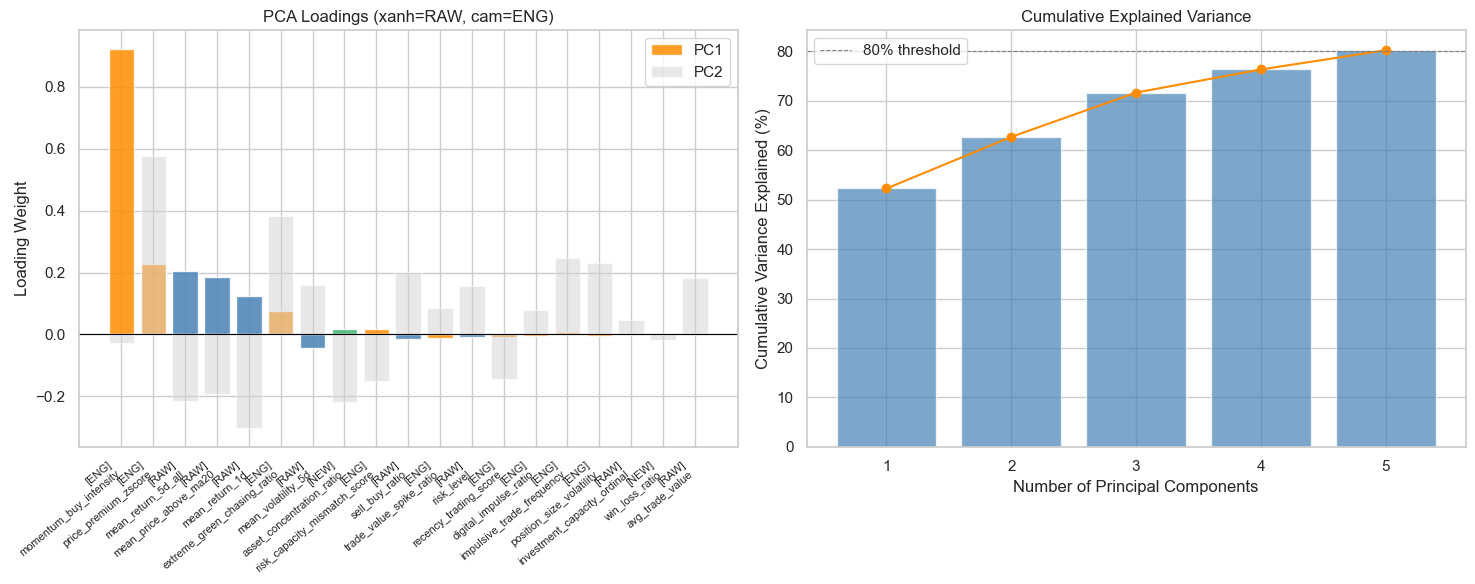

Explained variance by component:
  PC1: 52.24%
  PC2: 10.42%
  PC3: 8.96%
  PC4: 4.67%
  PC5: 3.89%

Top features by |PC1 loading|:
                                   PC1       PC2 source
momentum_buy_intensity        0.921161 -0.027640    ENG
price_premium_zscore          0.226991  0.577304    ENG
mean_return_5d_all            0.204438 -0.216419    RAW
mean_price_above_ma20         0.183998 -0.191158    RAW
mean_return_1d                0.123152 -0.302456    RAW
extreme_green_chasing_ratio   0.077097  0.382026    ENG
mean_volatility_5d           -0.044197  0.160850    RAW
asset_concentration_ratio     0.017949 -0.219541    NEW
risk_capacity_mismatch_score  0.016856 -0.150014    ENG
sell_buy_ratio               -0.015733  0.201128    RAW


In [44]:
pca = PCA(n_components=min(len(X_final.columns), 5))
pca.fit(X_final)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X_final.columns
)
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['source']  = loadings.index.map(FEATURE_SOURCE)
loadings = loadings.sort_values('PC1_abs', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart — màu theo source
bar_colors = [SOURCE_COLOR[FEATURE_SOURCE[c]] for c in loadings.index]
ax1.bar(range(len(loadings)), loadings['PC1'], color=bar_colors, alpha=0.85, label='PC1')
ax1.bar(range(len(loadings)), loadings['PC2'], color='lightgray', alpha=0.5, label='PC2')
ax1.set_xticks(range(len(loadings)))
ax1.set_xticklabels(
    [f"[{FEATURE_SOURCE[c]}]\n{c}" for c in loadings.index],
    rotation=40, ha='right', fontsize=8
)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('PCA Loadings (xanh=RAW, cam=ENG)', fontsize=12)
ax1.set_ylabel('Loading Weight')
ax1.legend()

# Cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
ax2.bar(range(1, len(cum_var)+1), cum_var, color='steelblue', alpha=0.7)
ax2.plot(range(1, len(cum_var)+1), cum_var, 'o-', color='darkorange')
ax2.axhline(80, color='gray', linestyle='--', linewidth=0.8, label='80% threshold')
ax2.set_title('Cumulative Explained Variance', fontsize=12)
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.legend()

plt.tight_layout()
plt.show()

print('Explained variance by component:')
for i, ev in enumerate(pca.explained_variance_ratio_, 1):
    print(f'  PC{i}: {ev*100:.2f}%')

print('\nTop features by |PC1 loading|:')
print(loadings[['PC1', 'PC2', 'source']].head(10))

### Step 7: Pairwise Distribution of Top Features

Visualize 3 features có PC1 loading cao nhất. Mỗi chấm = một nhà đầu tư.  
Các chấm nằm xa đám mây trung tâm (góc phần tư dương) là ứng viên FOMO mà clustering sẽ nhận diện.

Top 3 features by |PC1 loading|: ['momentum_buy_intensity', 'price_premium_zscore', 'mean_return_5d_all']
Sources: ['ENG', 'ENG', 'RAW']


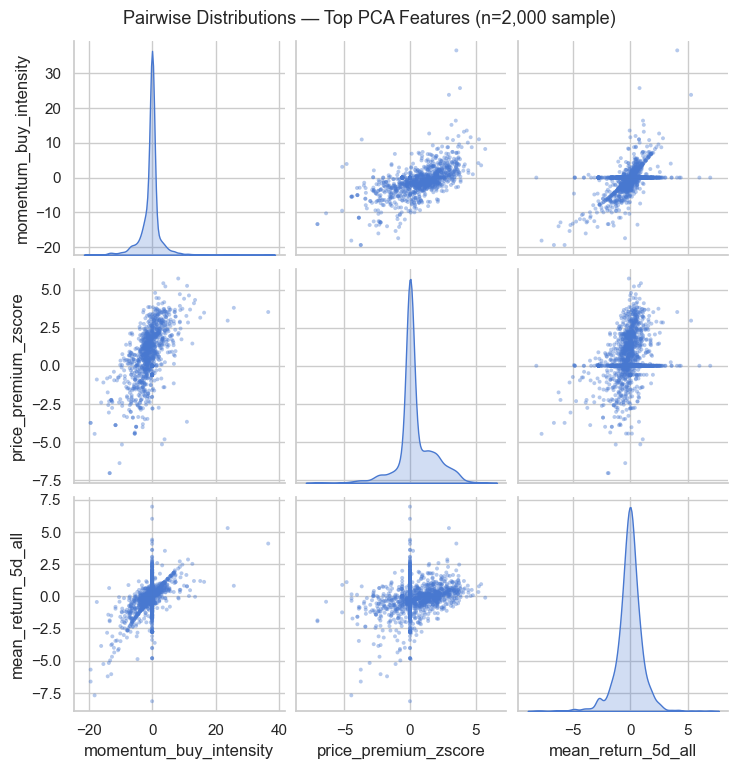

In [45]:
top_features = loadings.head(3).index.tolist()
print(f'Top 3 features by |PC1 loading|: {top_features}')
print(f'Sources: {[FEATURE_SOURCE[c] for c in top_features]}')

if len(top_features) >= 2:
    sample_size = min(2000, len(X_final))
    plot_df = X_final[top_features].sample(n=sample_size, random_state=42)
    g = sns.pairplot(
        plot_df, diag_kind='kde',
        plot_kws={'alpha': 0.4, 'edgecolor': 'none', 's': 8}
    )
    g.figure.suptitle(
        f'Pairwise Distributions — Top PCA Features (n={sample_size:,} sample)',
        y=1.02, fontsize=13
    )
    plt.show()

## 7. Final Summary & Export

In [46]:
# ── Summary ───────────────────────────────────────────────────────────────
final_raw_cols = [c for c in X_final.columns if FEATURE_SOURCE[c] == 'RAW']
final_eng_cols = [c for c in X_final.columns if FEATURE_SOURCE[c] == 'ENG']
final_new_cols = [c for c in X_final.columns if FEATURE_SOURCE[c] == 'NEW']

print('=' * 65)
print('FEATURE SELECTION PIPELINE — SUMMARY')
print('=' * 65)
print(f'  Investors                             : {len(X_final):,}')
print(f'  Start — total pool (RAW + ENG + NEW)  : {all_features.shape[1]}')
print(f'    Group A (raw aggregations)          : {raw_features.shape[1]}')
print(f'    Group B (engineered behavioral)     : {engineered_features.shape[1]}')
print(f'    Group C (sell-side + concentration) : {sell_features.shape[1]}')
print(f'  Dropped — variance < 0.01             : {len(dropped_by_var)}')
for c in dropped_by_var:
    print(f'      [{FEATURE_SOURCE[c]}] {c}')
print(f'  Dropped — Spearman |ρ| > 0.85         : {len(to_drop_corr)}')
for c in to_drop_corr:
    print(f'      [{FEATURE_SOURCE[c]}] {c}')
print(f'  Dropped — VIF > 5.0                   : {len(vif_dropped)}')
for feat, vif_val in vif_dropped:
    print(f'      [{FEATURE_SOURCE[feat]}] {feat}  (VIF={vif_val})')
print(f'  Final features                        : {X_final.shape[1]}')
print(f'    From Group A (raw)                  : {len(final_raw_cols)}')
print(f'    From Group B (engineered)           : {len(final_eng_cols)}')
print(f'    From Group C (new sell-side)        : {len(final_new_cols)}')
print('=' * 65)

print('\nFinal feature set (sorted by |PC1 loading|):')
for i, col in enumerate(loadings.index, 1):
    if col in X_final.columns:
        lv = loadings.loc[col, 'PC1']
        print(f'  [{FEATURE_SOURCE[col]}] {i:2d}. {col:<42} PC1={lv:+.3f}')

# ── Export ─────────────────────────────────────────────────────────────────
output_path = 'investor_behavior_features.csv'
X_final.to_csv(output_path, index=True)
print(f"\nExported {X_final.shape[1]} features × {len(X_final):,} investors → '{output_path}'")
X_final.head()


FEATURE SELECTION PIPELINE — SUMMARY
  Investors                             : 10,534
  Start — total pool (RAW + ENG + NEW)  : 27
    Group A (raw aggregations)          : 12
    Group B (engineered behavioral)     : 12
    Group C (sell-side + concentration) : 3
  Dropped — variance < 0.01             : 2
      [ENG] late_session_trade_bias
      [ENG] market_open_trade_bias
  Dropped — Spearman |ρ| > 0.85         : 3
      [RAW] mean_volatility_10d
      [RAW] mean_rsi_at_trade
      [ENG] short_interval_trade_ratio
  Dropped — VIF > 5.0                   : 3
      [RAW] trade_count  (VIF=16.35)
      [RAW] std_rsi_at_trade  (VIF=5.74)
      [NEW] avg_holding_period  (VIF=5.08)
  Final features                        : 19
    From Group A (raw)                  : 8
    From Group B (engineered)           : 9
    From Group C (new sell-side)        : 2

Final feature set (sorted by |PC1 loading|):
  [ENG]  1. momentum_buy_intensity                     PC1=+0.921
  [ENG]  2. price_pre

,risk_level,investment_capacity_ordinal,sell_buy_ratio,mean_volatility_5d,mean_return_1d,mean_return_5d_all,mean_price_above_ma20,avg_trade_value,extreme_green_chasing_ratio,price_premium_zscore,momentum_buy_intensity,position_size_volatility,risk_capacity_mismatch_score,trade_value_spike_ratio,impulsive_trade_frequency,digital_impulse_ratio,recency_trading_score,asset_concentration_ratio,win_loss_ratio
0004718496C71D464F57,-1.016334,1.485153,1.200371,1.213095,-2.359171,-0.953682,-1.659656,0.612561,0.0,-0.779224,-6.180523,0.210468,-1.871185,-0.074904,1.543325,-1.0,-1.227497,-0.815625,-0.390120
00090203A8C62E135D0B,-0.503734,0.000000,0.000000,0.412143,-1.363721,-0.138769,0.502464,-0.644512,0.0,0.000000,0.000000,-0.163063,0.000000,-0.566172,0.000000,0.0,0.056422,0.000000,-0.578917
001270E70A4ECA1CD664,0.496266,0.000000,0.955059,0.564445,-0.134386,1.689067,1.363474,0.923381,0.0,4.742296,9.417385,1.787819,0.000000,0.597892,0.000000,0.0,-0.847945,-1.160656,-0.578917
0017D195DFD87A91C59D,-1.539805,0.000000,0.000000,-0.239020,-0.572061,-0.843436,-0.242046,-0.182442,0.0,0.000000,0.000000,1.021135,0.000000,0.811708,1.000000,-1.0,0.571060,0.000000,-0.578917
001A82FE1591AD3926C7,-0.503734,1.000000,0.000000,0.394526,1.108971,0.513555,-0.272265,-1.483203,0.0,0.000000,0.000000,-0.158839,0.000000,0.597892,1.309557,-1.0,-0.250982,0.000000,0.421083
